In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use("ggplot")

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("D:/DLM Research/processed_data.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50778 entries, 0 to 50777
Data columns (total 32 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   patient_id                          50778 non-null  float64
 1   delivery_datetime                   50759 non-null  object 
 2   fundal_height_cm                    50778 non-null  int64  
 3   maternal_age_years                  50778 non-null  float64
 4   maternal_weight_kg                  50778 non-null  float64
 5   gestational_age_weeks               50778 non-null  object 
 6   fetal_presentation                  50778 non-null  object 
 7   fetal_lie                           50778 non-null  object 
 8   placenta_status                     50778 non-null  object 
 9   maternal_outcome_status             50778 non-null  object 
 10  history_hypertension                50778 non-null  float64
 11  history_diabetes                    50778

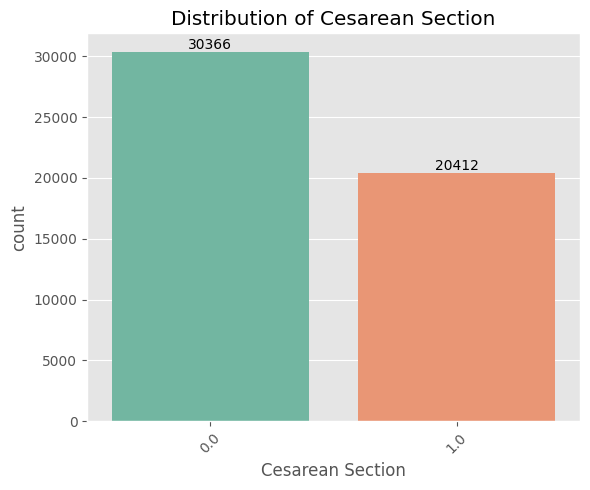

In [4]:
plt.figure(figsize=(6,5))

ax = sns.countplot(x='Cesarean Section', data=df, palette='Set2')

for container in ax.containers:
    ax.bar_label(container)

plt.title("Distribution of Cesarean Section")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

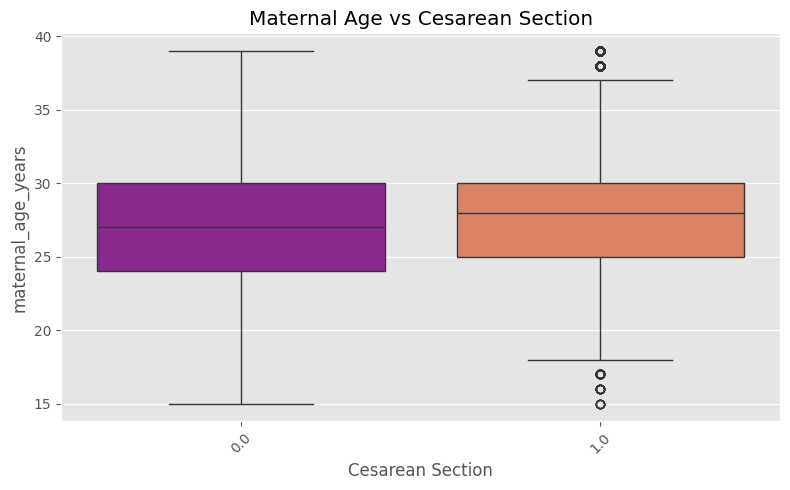

In [5]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Cesarean Section', y='maternal_age_years', data=df, palette='plasma')

plt.title("Maternal Age vs Cesarean Section")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

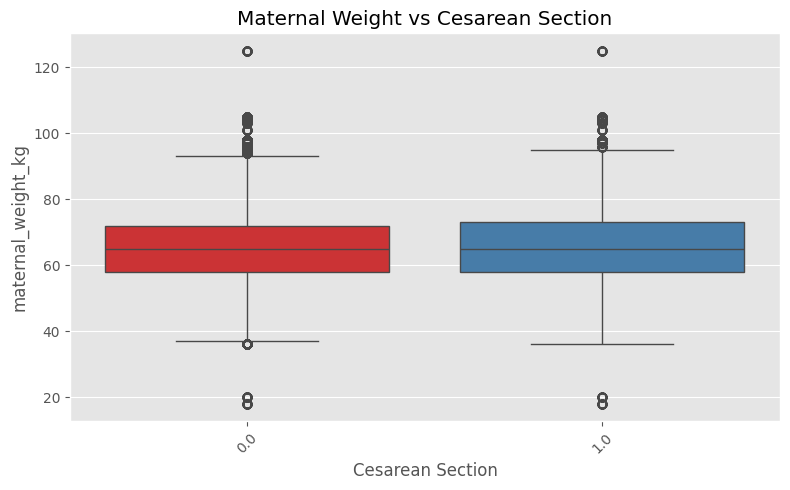

In [6]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Cesarean Section', y='maternal_weight_kg', data=df, palette='Set1')

plt.title("Maternal Weight vs Cesarean Section")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

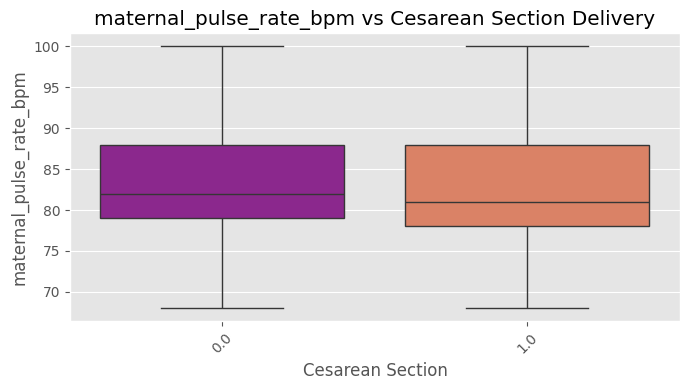

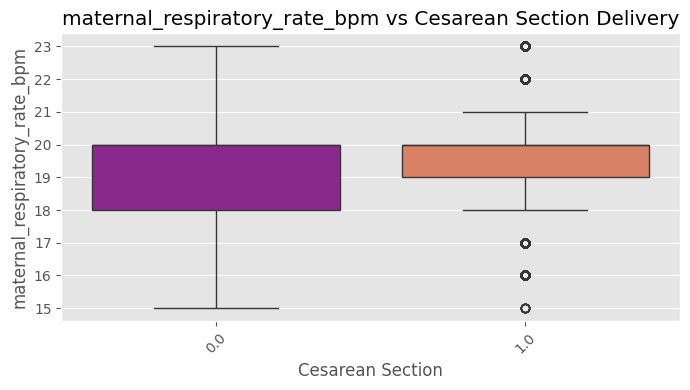

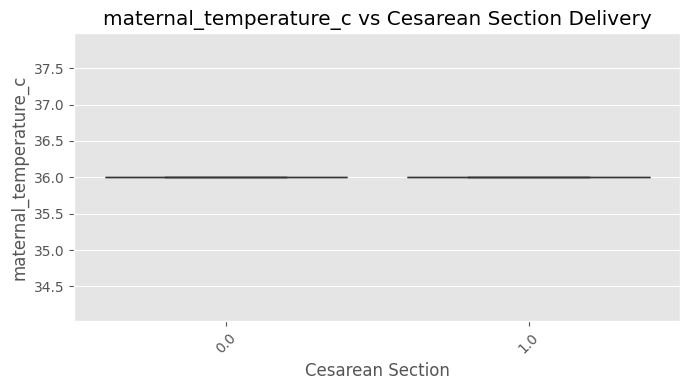

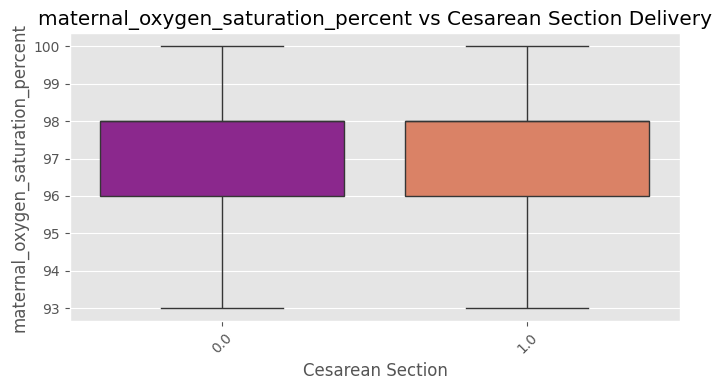

In [7]:
vitals = [
    'maternal_pulse_rate_bpm',
    'maternal_respiratory_rate_bpm',
    'maternal_temperature_c',
    'maternal_oxygen_saturation_percent'
]

for col in vitals:
    plt.figure(figsize=(7,4))
    sns.boxplot(x='Cesarean Section', y=col, data=df, palette='plasma')
    plt.title(f"{col} vs Cesarean Section Delivery")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

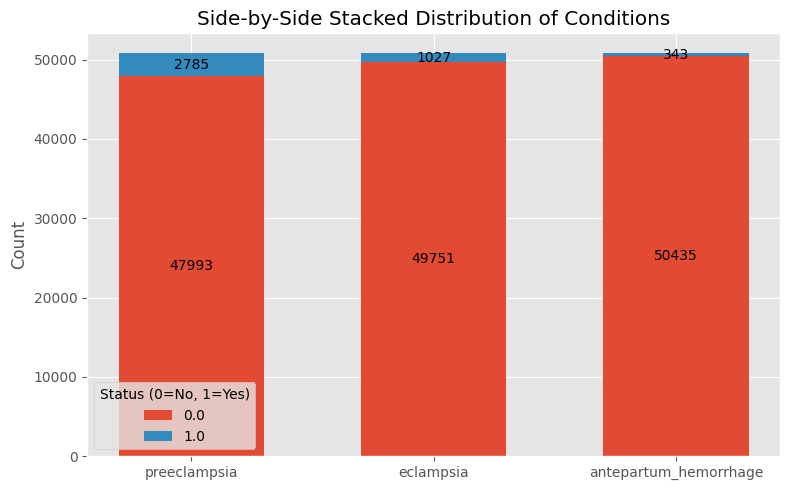

In [8]:
conditions = ['preeclampsia', 'eclampsia', 'antepartum_hemorrhage']

# Prepare counts (assuming binary 0/1)
data = []
for col in conditions:
    counts = df[col].value_counts().sort_index()  # 0,1
    data.append(counts)

stacked_df = pd.DataFrame(data, index=conditions).fillna(0)

# Ensure columns order (0 then 1)
stacked_df = stacked_df[[0, 1]]  

# Plot
x = np.arange(len(conditions))
width = 0.6

fig, ax = plt.subplots(figsize=(8,5))

# Bottom starts at 0
bottom = np.zeros(len(conditions))

for i, col in enumerate(stacked_df.columns):
    ax.bar(x, stacked_df[col], width, bottom=bottom, label=f"{col}")
    bottom += stacked_df[col].values

# Labels
ax.set_xticks(x)
ax.set_xticklabels(conditions, rotation=0)
ax.set_title("Side-by-Side Stacked Distribution of Conditions")
ax.set_ylabel("Count")
ax.legend(title="Status (0=No, 1=Yes)")

# Add labels
for i in range(len(conditions)):
    cumulative = 0
    for col in stacked_df.columns:
        value = stacked_df.loc[conditions[i], col]
        if value > 0:
            ax.text(i, cumulative + value/2, int(value), ha='center', va='center')
            cumulative += value

plt.tight_layout()
plt.show()

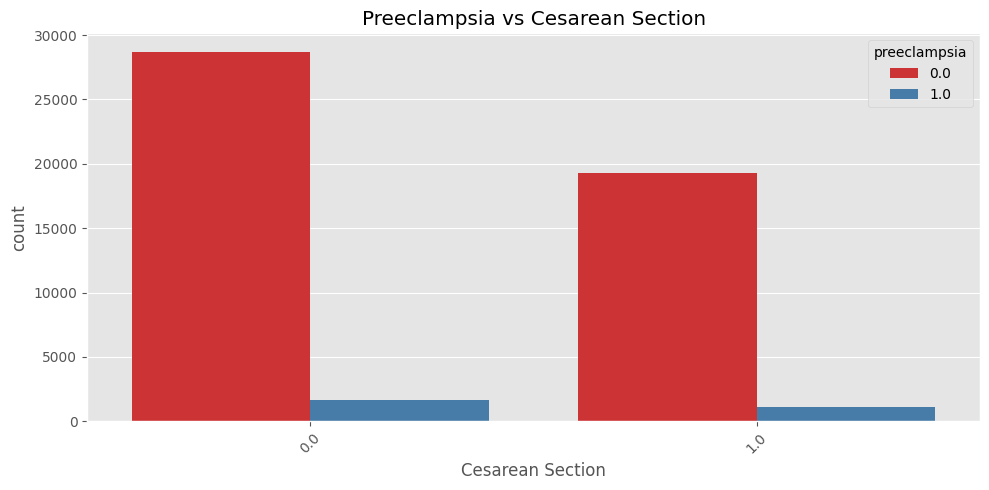

In [9]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='Cesarean Section',
    hue='preeclampsia',
    data=df,
    palette='Set1'
)

plt.title("Preeclampsia vs Cesarean Section")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

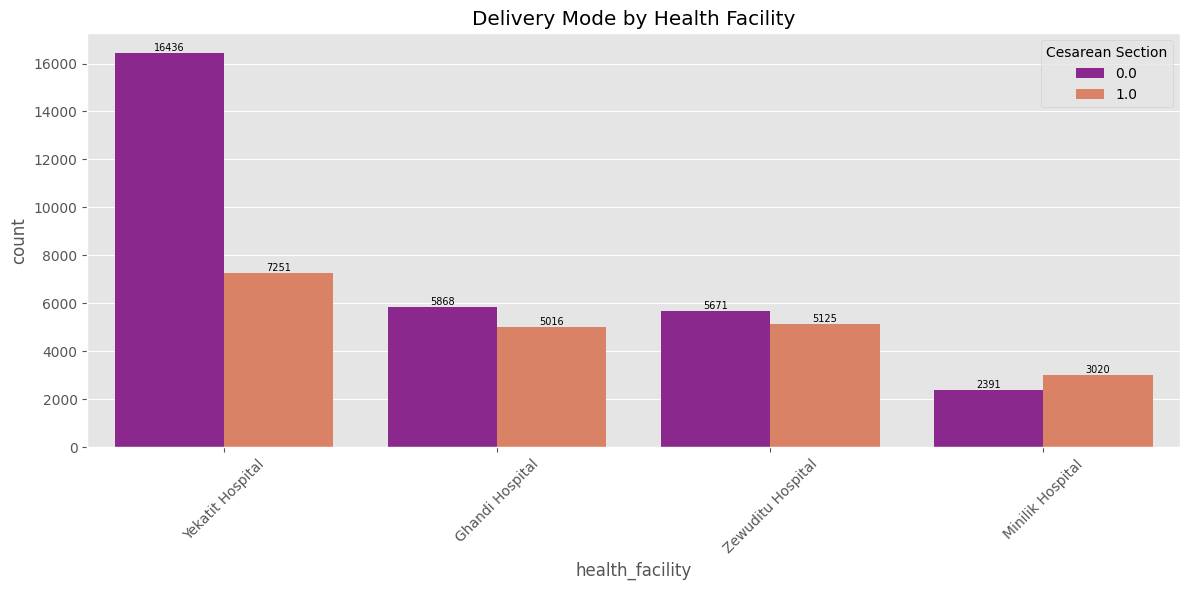

In [10]:
plt.figure(figsize=(12,6))

order = df['health_facility'].value_counts().index

ax = sns.countplot(
    x='health_facility',
    hue='Cesarean Section',
    data=df,
    order=order,
    palette='plasma'
)

for container in ax.containers:
    ax.bar_label(container, fontsize=7)

plt.xticks(rotation=45)
plt.title("Delivery Mode by Health Facility")
plt.tight_layout()
plt.show()

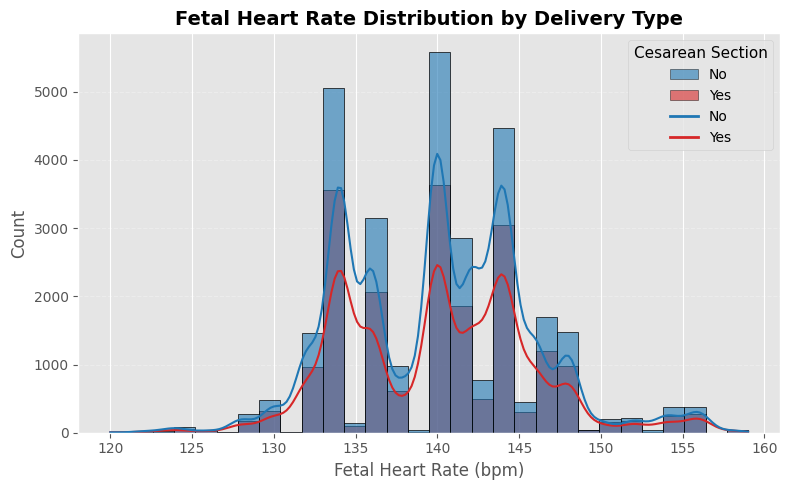

In [11]:
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

plt.figure(figsize=(8,5))

ax = sns.histplot(
    data=df,
    x='fetal_heart_rate_bpm',
    hue='Cesarean Section',
    bins=30,
    kde=True,
    palette=['#1f77b4', '#d62728'],
    alpha=0.6,
    edgecolor='black',
    linewidth=0.5
)

plt.title("Fetal Heart Rate Distribution by Delivery Type", fontsize=14, weight='bold')
plt.xlabel("Fetal Heart Rate (bpm)", fontsize=12)
plt.ylabel("Count", fontsize=12)

# --- Custom Legend ---
legend_elements = [
    Patch(facecolor='#1f77b4', edgecolor='black', label='No', alpha=0.6),
    Patch(facecolor='#d62728', edgecolor='black', label='Yes', alpha=0.6),
    Line2D([0], [0], color='#1f77b4', lw=2, label='No'),
    Line2D([0], [0], color='#d62728', lw=2, label='Yes')
]

plt.legend(
    handles=legend_elements,
    title="Cesarean Section",
    title_fontsize=11,
    fontsize=10
)

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

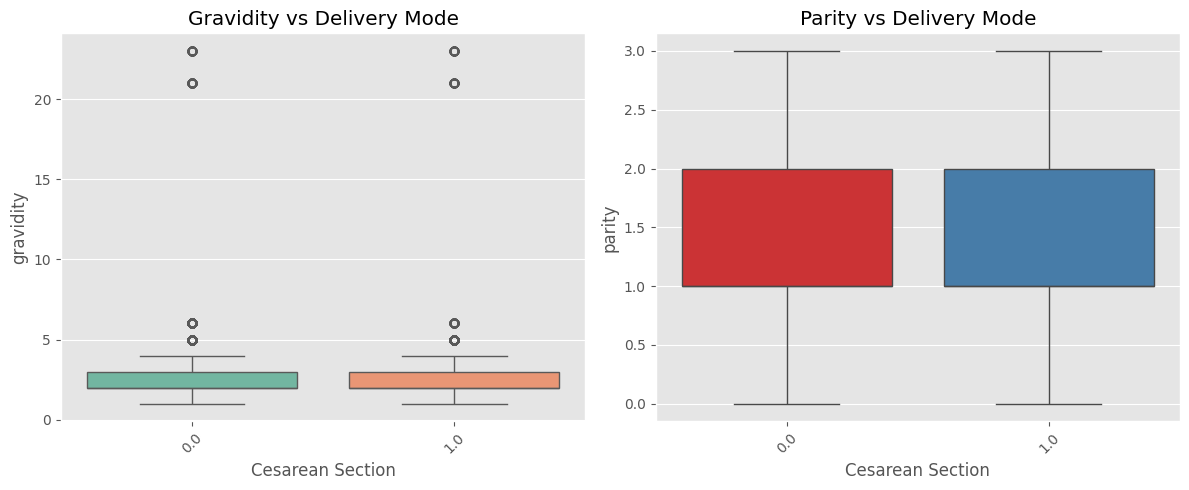

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x='Cesarean Section', y='gravidity', data=df, ax=axes[0], palette='Set2')
axes[0].set_title("Gravidity vs Delivery Mode")
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(x='Cesarean Section', y='parity', data=df, ax=axes[1], palette='Set1')
axes[1].set_title("Parity vs Delivery Mode")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

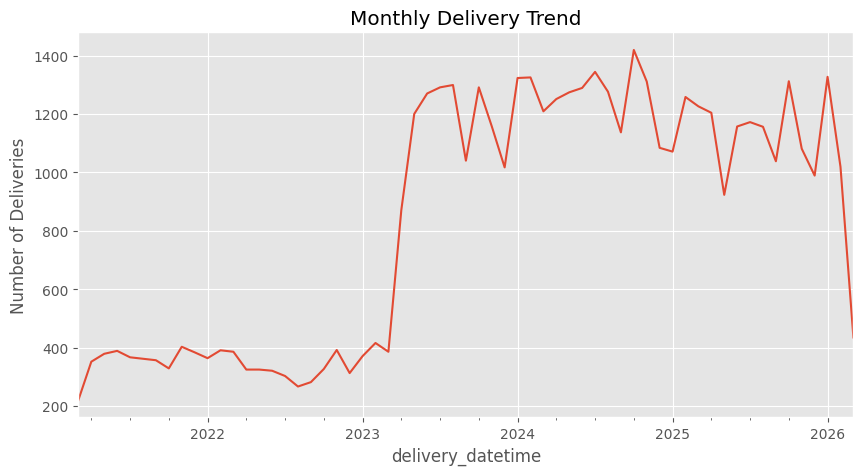

In [13]:
df['delivery_datetime'] = pd.to_datetime(df['delivery_datetime'], errors='coerce')

df.groupby(df['delivery_datetime'].dt.to_period('M')).size().plot(figsize=(10,5))

plt.title("Monthly Delivery Trend")
plt.ylabel("Number of Deliveries")
plt.show()

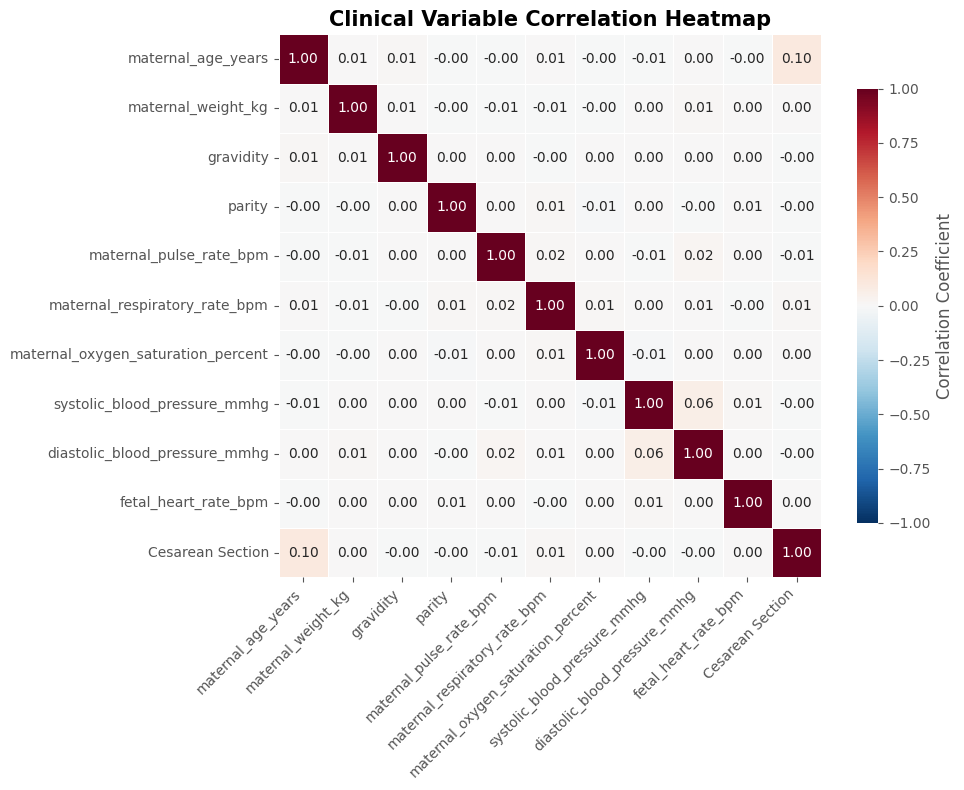

In [14]:
selected_cols = [
    'maternal_age_years', 'maternal_weight_kg',
    'gravidity', 'parity',
    'maternal_pulse_rate_bpm',
    'maternal_respiratory_rate_bpm',
    'maternal_oxygen_saturation_percent',
    'systolic_blood_pressure_mmhg',
    'diastolic_blood_pressure_mmhg',
    'fetal_heart_rate_bpm',
    'Cesarean Section'
]

corr_df = df[selected_cols].copy().dropna()
corr = corr_df.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    cmap='RdBu_r',          # 🔥 BEST for correlations (blue ↔ red)
    vmin=-1, vmax=1,        # consistent scale
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8, "label": "Correlation Coefficient"}
)

plt.title("Clinical Variable Correlation Heatmap", fontsize=15, weight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

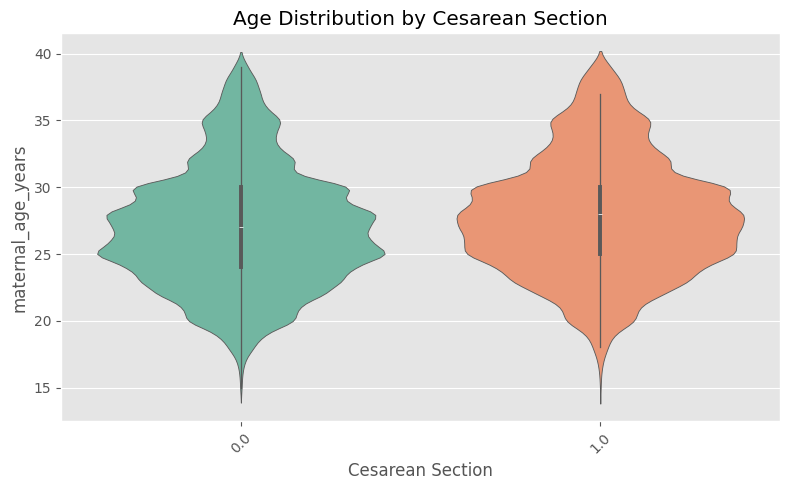

In [15]:
plt.figure(figsize=(8,5))

sns.violinplot(
    x='Cesarean Section',
    y='maternal_age_years',
    data=df,
    palette='Set2'
)

plt.title("Age Distribution by Cesarean Section")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

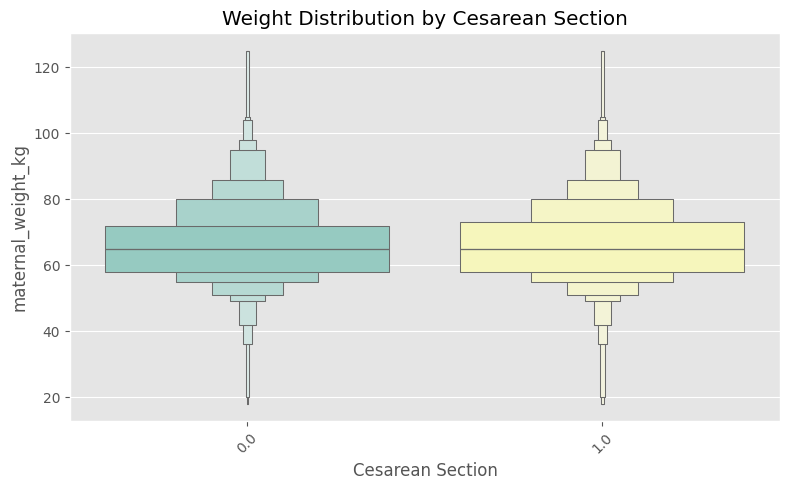

In [16]:
plt.figure(figsize=(8,5))

sns.boxenplot(
    x='Cesarean Section',
    y='maternal_weight_kg',
    data=df,
    palette='Set3'
)

plt.title("Weight Distribution by Cesarean Section")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

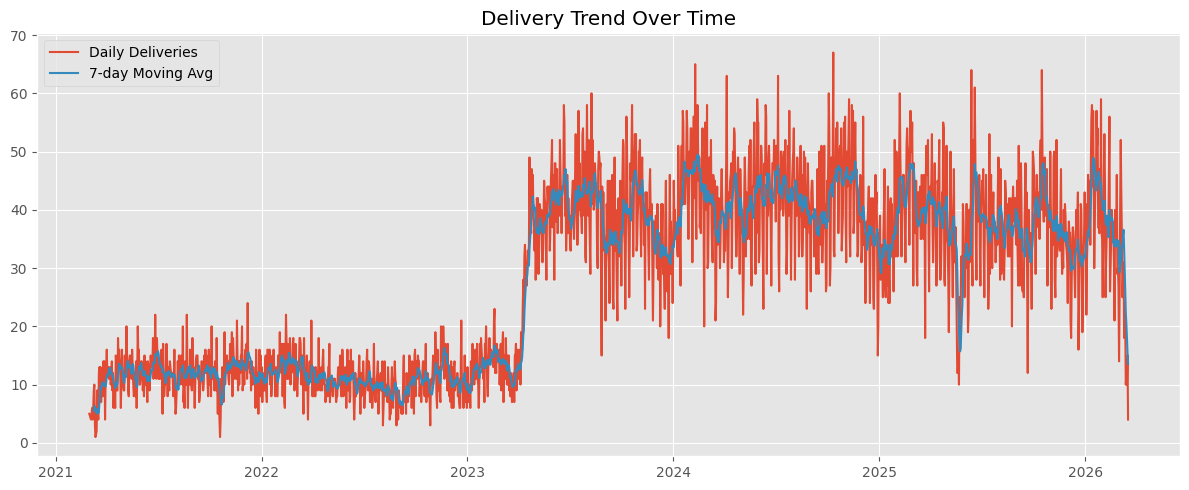

In [17]:
df['delivery_datetime'] = pd.to_datetime(df['delivery_datetime'], errors='coerce')

time_series = df.groupby(df['delivery_datetime'].dt.date).size()

rolling = time_series.rolling(7).mean()

plt.figure(figsize=(12,5))

plt.plot(time_series, label='Daily Deliveries')
plt.plot(rolling, label='7-day Moving Avg')

plt.title("Delivery Trend Over Time")
plt.legend()
plt.tight_layout()
plt.show()

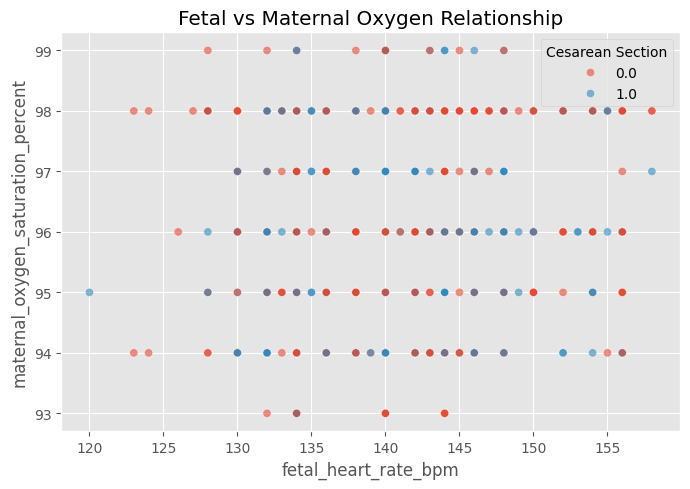

In [18]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    x='fetal_heart_rate_bpm',
    y='maternal_oxygen_saturation_percent',
    hue='Cesarean Section',
    data=df.sample(2000),
    alpha=0.6
)

plt.title("Fetal vs Maternal Oxygen Relationship")
plt.tight_layout()
plt.show()

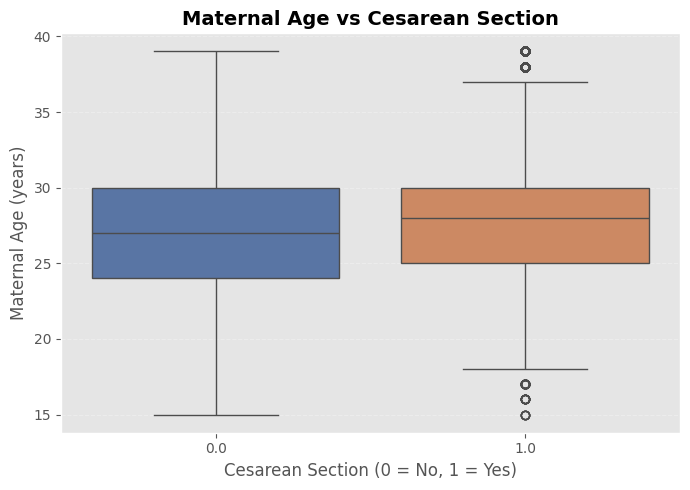

In [19]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x='Cesarean Section',
    y='maternal_age_years',
    palette=['#4C72B0', '#DD8452']
)

plt.title("Maternal Age vs Cesarean Section", fontsize=14, weight='bold')
plt.xlabel("Cesarean Section (0 = No, 1 = Yes)")
plt.ylabel("Maternal Age (years)")

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

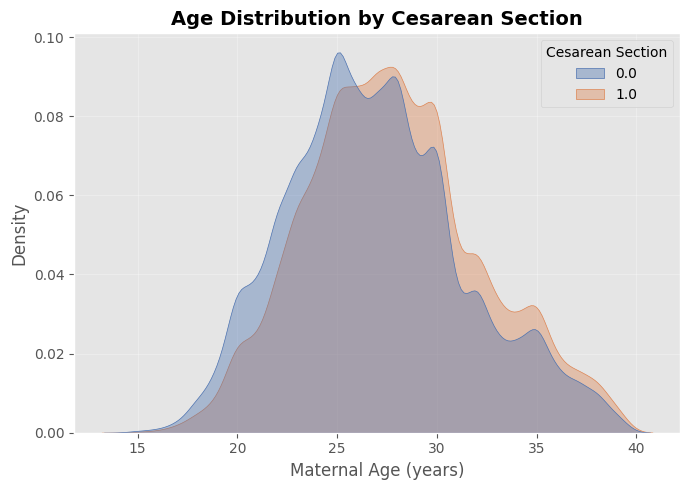

In [20]:
plt.figure(figsize=(7,5))

sns.kdeplot(
    data=df,
    x='maternal_age_years',
    hue='Cesarean Section',
    fill=True,
    common_norm=False,
    palette=['#4C72B0', '#DD8452'],
    alpha=0.4
)

plt.title("Age Distribution by Cesarean Section", fontsize=14, weight='bold')
plt.xlabel("Maternal Age (years)")
plt.ylabel("Density")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

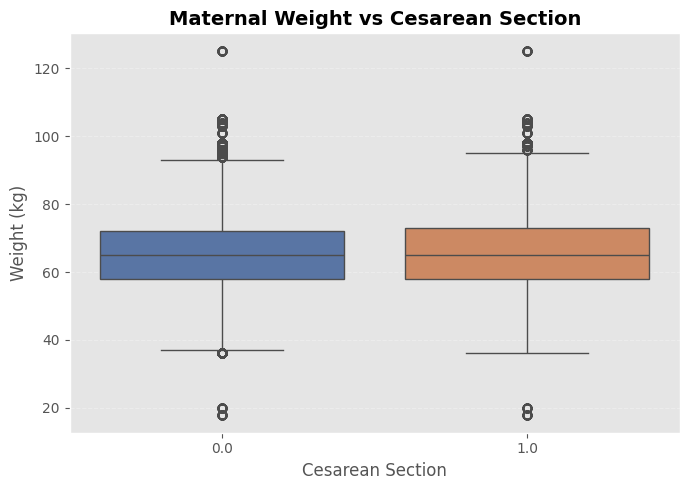

In [21]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x='Cesarean Section',
    y='maternal_weight_kg',
    palette=['#4C72B0', '#DD8452']
)

plt.title("Maternal Weight vs Cesarean Section", fontsize=14, weight='bold')
plt.xlabel("Cesarean Section")
plt.ylabel("Weight (kg)")

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

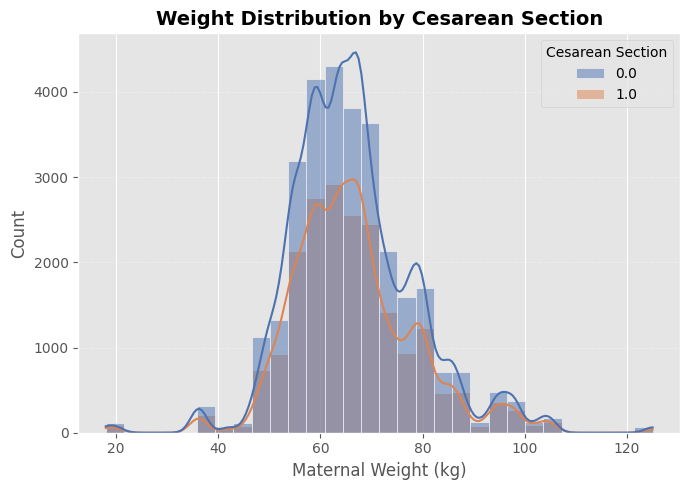

In [22]:
plt.figure(figsize=(7,5))

sns.histplot(
    data=df,
    x='maternal_weight_kg',
    hue='Cesarean Section',
    bins=30,
    kde=True,
    palette=['#4C72B0', '#DD8452'],
    alpha=0.5
)

plt.title("Weight Distribution by Cesarean Section", fontsize=14, weight='bold')
plt.xlabel("Maternal Weight (kg)")
plt.ylabel("Count")

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

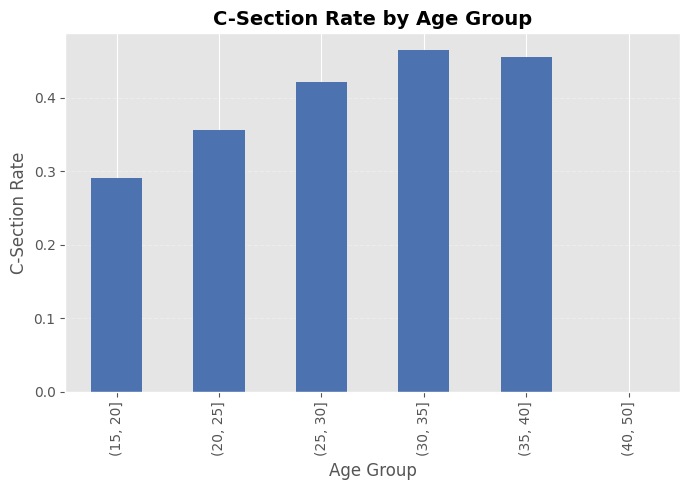

In [23]:
df['age_group'] = pd.cut(
    df['maternal_age_years'],
    bins=[15, 20, 25, 30, 35, 40, 50]
)

age_cs = df.groupby('age_group')['Cesarean Section'].mean()

age_cs.plot(kind='bar', figsize=(7,5), color='#4C72B0')

plt.title("C-Section Rate by Age Group", fontsize=14, weight='bold')
plt.ylabel("C-Section Rate")
plt.xlabel("Age Group")

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

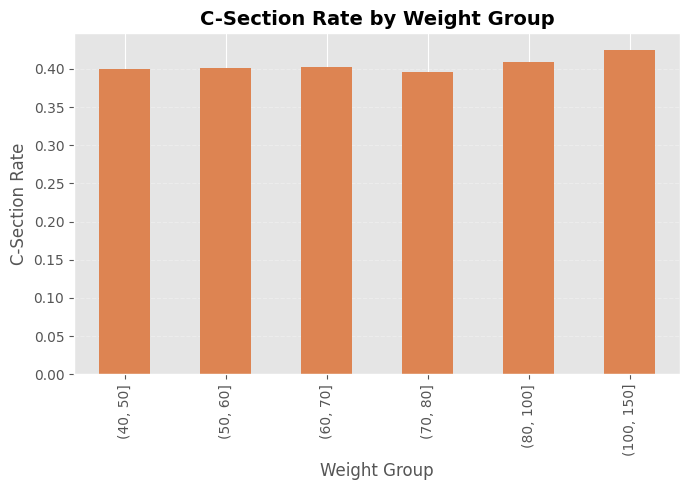

In [24]:
df['weight_group'] = pd.cut(
    df['maternal_weight_kg'],
    bins=[40, 50, 60, 70, 80, 100, 150]
)

weight_cs = df.groupby('weight_group')['Cesarean Section'].mean()

weight_cs.plot(kind='bar', figsize=(7,5), color='#DD8452')

plt.title("C-Section Rate by Weight Group", fontsize=14, weight='bold')
plt.ylabel("C-Section Rate")
plt.xlabel("Weight Group")

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

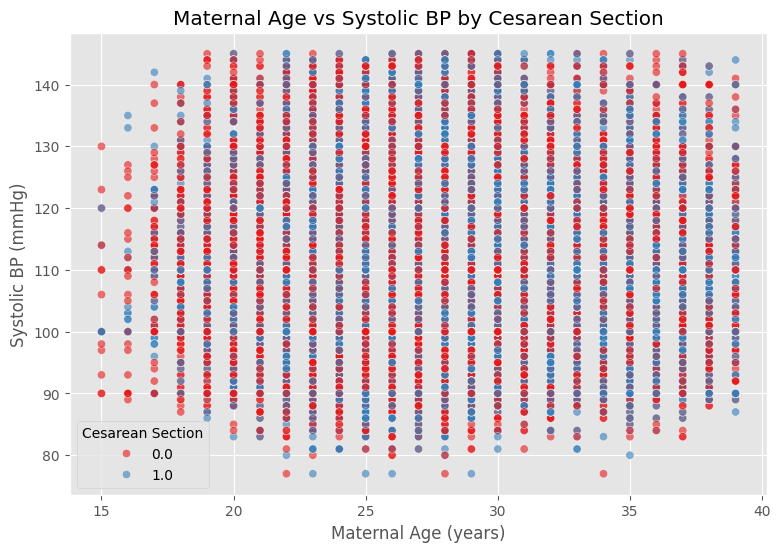

In [25]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df,
    x='maternal_age_years',
    y='systolic_blood_pressure_mmhg',
    hue='Cesarean Section',
    alpha=0.6,
    palette='Set1'
)

plt.title("Maternal Age vs Systolic BP by Cesarean Section")
plt.xlabel("Maternal Age (years)")
plt.ylabel("Systolic BP (mmHg)")
plt.show()

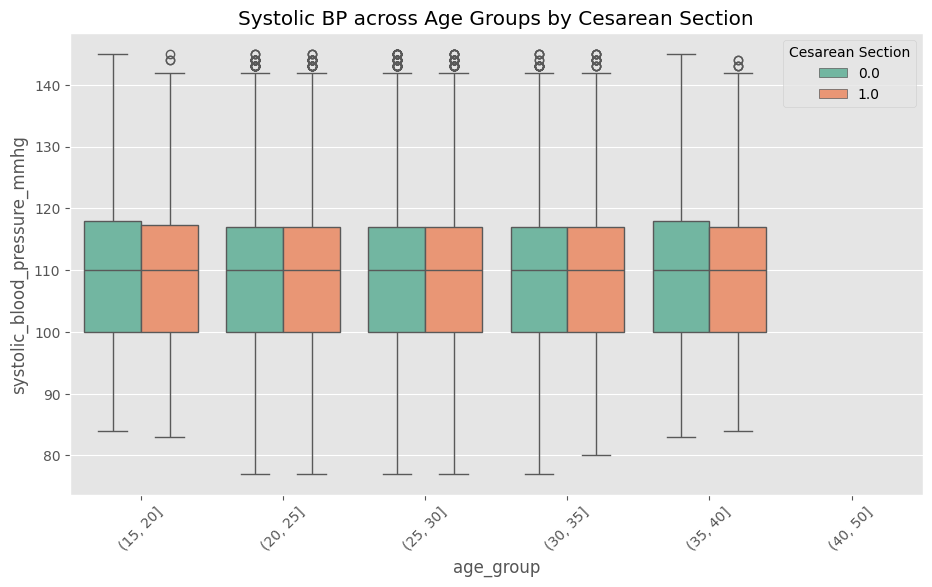

In [26]:
plt.figure(figsize=(11,6))

sns.boxplot(
    data=df,
    x='age_group',
    y='systolic_blood_pressure_mmhg',
    hue='Cesarean Section',
    palette='Set2'
)

plt.title("Systolic BP across Age Groups by Cesarean Section")
plt.xticks(rotation=45)
plt.show()

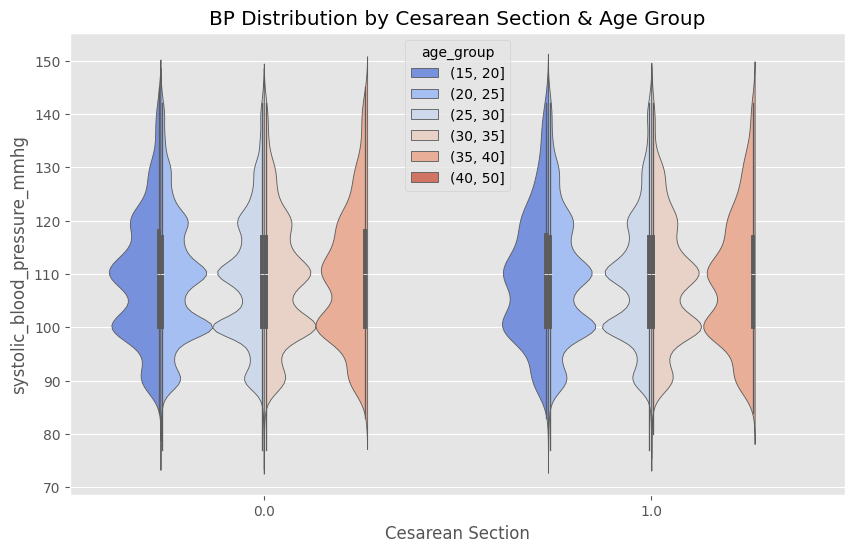

In [27]:
plt.figure(figsize=(10,6))

sns.violinplot(
    data=df,
    x='Cesarean Section',
    y='systolic_blood_pressure_mmhg',
    hue='age_group',
    split=True,
    palette='coolwarm'
)

plt.title("BP Distribution by Cesarean Section & Age Group")
plt.show()

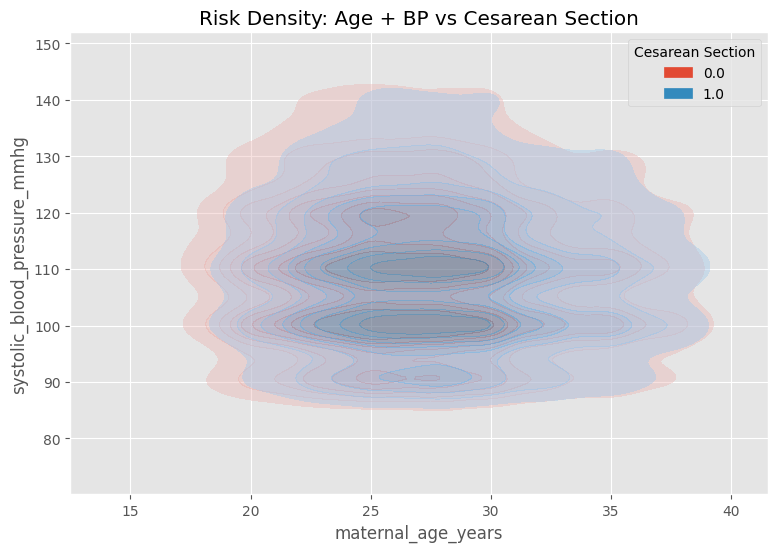

In [28]:
plt.figure(figsize=(9,6))

sns.kdeplot(
    data=df,
    x='maternal_age_years',
    y='systolic_blood_pressure_mmhg',
    hue='Cesarean Section',
    fill=True,
    alpha=0.4
)

plt.title("Risk Density: Age + BP vs Cesarean Section")
plt.show()